# Polar Decoder v2 — Improved Architecture with Iterative Refinement

**Key improvements over v1:**
- 128 radii (up from 64) for finer angular resolution
- Per-angle cross-attention decoder (replaces global average pooling)
- Fourier contour descriptor auxiliary loss
- Deep Snake-style iterative refinement (graph convolution on contour)
- Multi-centroid detection for concave wounds
- Contour refinement loss against raw binary mask edges (distance transform)
- Fixed evaluation: IoU computed against raw mask, not polar-converted GT
- Qualitative plots: 2 images per real dataset (Medetec, FUSeg, AZH)

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'einops'])

import os, json, math, random, glob as _glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), 'No GPU! Select T4 x2 in Kaggle Settings.'
_cc = torch.cuda.get_device_capability(0)
assert _cc[0]*10+_cc[1] >= 70, f'GPU sm_{_cc[0]}{_cc[1]} too old. Select T4 x2.'
device = torch.device('cuda')
print(f'GPU: {torch.cuda.get_device_name(0)} | PyTorch: {torch.__version__}')

# ── Config ────────────────────────────────────────────────────────────────────
NUM_RADII   = 128        # v2: doubled from 64
IMAGE_SIZE  = 256
D_MODEL     = 256
BATCH       = 6          # slightly smaller for larger model
MAX_EPOCHS  = 50
LR          = 1e-4
PATIENCE    = 15

for d in ['results/polar_v2', 'figures/polar_v2']:
    Path(d).mkdir(parents=True, exist_ok=True)
print('Setup complete.')

GPU: Tesla T4 | PyTorch: 2.10.0+cu128
Setup complete.


## 1. Data Loading (Fixed — No Recursive __getitem__)

In [2]:
# ─── Dataset Paths ─────────────────────────────────────────────────────────
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

_candidates = [
    Path('/kaggle/input/datasets/dianisay/wound-datasets/Datasets'),
    Path('/kaggle/input/wound-datasets/Datasets'),
    Path('/kaggle/input/datasets/dianisay/wound-datasets'),
    Path('/kaggle/input/wound-datasets'),
    Path('data/wound-datasets'),  # local fallback
]
BASE_PATH = next((p for p in _candidates if p.exists()), _candidates[0])
print(f'BASE_PATH: {BASE_PATH} (exists={BASE_PATH.exists()})')

WOUND_DATASETS = [
    {'name': 'FUSeg', 'root': BASE_PATH / 'Foot Ulcer Segmentation Challenge',
     'splits': {'train': ('train/images', 'train/labels'),
                'val': ('validation/images', 'validation/labels'),
                'test': ('test/images', None)}},
    {'name': 'Medetec', 'root': BASE_PATH / 'Medetec_foot_ulcer_224',
     'splits': {'train': ('train/images', 'train/labels'),
                'test': ('test/images', 'test/labels')}},
    {'name': 'AZH', 'root': BASE_PATH / 'wound_dataset' / 'azh_wound_care_center_dataset_patches',
     'splits': {'train': ('train/images', 'train/labels'),
                'test': ('test/images', 'test/labels')}},
]

def load_wound_pairs(datasets, split='train'):
    pairs = []
    for ds in datasets:
        root = ds['root']
        if not root.exists(): continue
        if split in ds['splits']:
            img_rel, lbl_rel = ds['splits'][split]
        elif split == 'val' and 'test' in ds['splits']:
            img_rel, lbl_rel = ds['splits']['test']
        else: continue
        img_dir = root / img_rel
        lbl_dir = root / lbl_rel if lbl_rel else None
        if not img_dir.exists(): continue
        imgs = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS])
        if lbl_dir and lbl_dir.exists():
            lbl_files = {p.stem.lower(): p for p in lbl_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS}
            for img_p in imgs:
                mask_p = lbl_files.get(img_p.stem.lower())
                if mask_p:
                    pairs.append((img_p, mask_p, ds['name']))
    return pairs

train_pairs = load_wound_pairs(WOUND_DATASETS, 'train')
val_pairs   = load_wound_pairs(WOUND_DATASETS, 'val')
test_pairs  = load_wound_pairs(WOUND_DATASETS, 'test')
USE_REAL_DATA = len(train_pairs) > 0
print(f'Real data: train={len(train_pairs)}, val={len(val_pairs)}, test={len(test_pairs)}')

BASE_PATH: /kaggle/input/datasets/dianisay/wound-datasets/Datasets (exists=True)
Real data: train=1793, val=486, test=286


In [3]:
# ─── Robust mask_to_polar (handles concave, multi-component masks) ──────────

def mask_to_polar(mask, num_radii=NUM_RADII, image_size=IMAGE_SIZE):
    """Convert binary mask to polar representation.
    Returns None if mask is unsuitable for polar conversion."""
    if mask.max() <= 1:
        mask_bin = (mask > 0).astype(np.uint8) * 255
    else:
        mask_bin = (mask > 127).astype(np.uint8) * 255

    ys, xs = np.where(mask_bin > 0)
    if len(xs) < 50:
        return None

    cx = float(xs.mean()) / mask_bin.shape[1]
    cy = float(ys.mean()) / mask_bin.shape[0]

    # If centroid is outside mask, use median
    cpx, cpy = int(cx * mask_bin.shape[1]), int(cy * mask_bin.shape[0])
    cpx = np.clip(cpx, 0, mask_bin.shape[1]-1)
    cpy = np.clip(cpy, 0, mask_bin.shape[0]-1)
    if mask_bin[cpy, cpx] == 0:
        cx = float(np.median(xs)) / mask_bin.shape[1]
        cy = float(np.median(ys)) / mask_bin.shape[0]

    angles = np.linspace(0, 2*np.pi, num_radii, endpoint=False)
    radii  = np.zeros(num_radii, dtype=np.float32)
    cxp, cyp = cx * mask_bin.shape[1], cy * mask_bin.shape[0]
    max_r = max(mask_bin.shape) * 0.7

    for i, ang in enumerate(angles):
        dx, dy = np.cos(ang), np.sin(ang)
        for step in range(1, int(max_r)):
            px = int(cxp + dx * step)
            py = int(cyp + dy * step)
            if px < 0 or px >= mask_bin.shape[1] or py < 0 or py >= mask_bin.shape[0]:
                radii[i] = step / max(mask_bin.shape)
                break
            if mask_bin[py, px] == 0:
                radii[i] = step / max(mask_bin.shape)
                break
        else:
            radii[i] = max_r / max(mask_bin.shape)

    min_radius = 3.0 / max(mask_bin.shape)
    if (radii > min_radius).sum() < num_radii * 0.5:
        return None
    radii = np.maximum(radii, min_radius)

    points = np.stack([
        cx + radii * np.cos(angles),
        cy + radii * np.sin(angles),
    ], axis=1).astype(np.float32)

    # Compute concavity score: count how many rays exit+re-enter the mask
    # This provides supervision for the multi-centroid head
    concavity_crossings = 0
    for i, ang in enumerate(angles):
        dx, dy = np.cos(ang), np.sin(ang)
        inside = True
        crossings = 0
        for step in range(1, int(max_r)):
            px_s = int(cx * mask_bin.shape[1] + dx * step)
            py_s = int(cy * mask_bin.shape[0] + dy * step)
            if px_s < 0 or px_s >= mask_bin.shape[1] or py_s < 0 or py_s >= mask_bin.shape[0]:
                break
            pixel_in = mask_bin[py_s, px_s] > 0
            if inside and not pixel_in:
                inside = False
                crossings += 1
            elif not inside and pixel_in:
                inside = True
                crossings += 1
        if crossings > 2:  # ray exits and re-enters
            concavity_crossings += 1

    # n_centroids: 1 if star-convex, 2 if mildly concave, 3 if heavily concave
    concavity_ratio = concavity_crossings / num_radii
    if concavity_ratio > 0.3:
        n_centroids = 3
    elif concavity_ratio > 0.1:
        n_centroids = 2
    else:
        n_centroids = 1

    return {
        'centroid': np.array([cx, cy], dtype=np.float32),
        'radii': radii,
        'points': points,
        'n_centroids': n_centroids,
        'concavity_ratio': float(concavity_ratio),
    }

print('mask_to_polar defined (with concavity detection).')

mask_to_polar defined (with concavity detection).


In [4]:
# ─── WoundDataset v2: NO recursive __getitem__, stores raw mask for loss ─────

class WoundDatasetV2(Dataset):
    """Fixed dataset: skips invalid samples at init time, stores raw mask."""
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, real_pairs=None, synthetic_dir=None,
                 image_size=IMAGE_SIZE, num_radii=NUM_RADII, augment=True):
        self.image_size = image_size
        self.num_radii  = num_radii
        self.augment    = augment
        self.normalize  = T.Normalize(self.MEAN, self.STD)
        self.valid_samples = []  # pre-validated list

        # Pre-validate all real pairs (skip bad masks upfront)
        n_skipped = 0
        if real_pairs:
            for item in real_pairs:
                img_path, mask_path = item[0], item[1]
                ds_name = item[2] if len(item) > 2 else 'unknown'
                try:
                    mask = np.array(Image.open(mask_path).convert('L').resize(
                        (image_size, image_size), Image.NEAREST))
                    label = mask_to_polar(mask, num_radii, image_size)
                    if label is not None:
                        self.valid_samples.append({
                            'img_path': img_path, 'mask_path': mask_path,
                            'label': label, 'ds_name': ds_name, 'is_synthetic': False
                        })
                    else:
                        n_skipped += 1
                except Exception:
                    n_skipped += 1

        # Synthetic data
        if synthetic_dir and Path(synthetic_dir, 'labels.npz').exists():
            data = np.load(Path(synthetic_dir) / 'labels.npz')
            imgs_dir = Path(synthetic_dir) / 'images'
            for i in range(len(data['centroids'])):
                lbl = {'centroid': data['centroids'][i].astype(np.float32),
                       'radii': data['radii'][i].astype(np.float32),
                       'points': data['points'][i].astype(np.float32)}
                self.valid_samples.append({
                    'img_path': imgs_dir / f'{i:05d}.png', 'mask_path': None,
                    'label': lbl, 'ds_name': 'synthetic', 'is_synthetic': True
                })

        if n_skipped > 0:
            print(f'  Skipped {n_skipped} invalid samples at init time.')
        print(f'  Valid samples: {len(self.valid_samples)}')

    def __len__(self):
        return len(self.valid_samples)

    def __getitem__(self, idx):
        sample = self.valid_samples[idx]
        img_pil = Image.open(sample['img_path']).convert('RGB').resize(
            (self.image_size, self.image_size), Image.BILINEAR)
        img_np = np.array(img_pil)
        label = {k: v.copy() if isinstance(v, np.ndarray) else v
                 for k, v in sample['label'].items()}

        # Load raw mask for contour loss (None for synthetic)
        raw_mask = None
        if sample['mask_path'] is not None:
            raw_mask = np.array(Image.open(sample['mask_path']).convert('L').resize(
                (self.image_size, self.image_size), Image.NEAREST))
            if raw_mask.max() <= 1:
                raw_mask = raw_mask * 255

        # Augmentation (strong, skin-tone-aware)
        if self.augment:
            img_np, label = self._augment(img_np, label)

        # To tensor
        img_t = torch.from_numpy(img_np.copy()).permute(2,0,1).float() / 255.0
        img_t = self.normalize(img_t)

        # Always return a mask tensor (zeros for synthetic) for batching
        if raw_mask is not None:
            mask_t = torch.from_numpy(raw_mask).float() / 255.0
        else:
            mask_t = torch.zeros(self.image_size, self.image_size)

        # Multi-centroid supervision: n_centroids (0-indexed class label)
        n_centroids = label.get('n_centroids', 1)  # default star-convex

        return {
            'image': img_t,
            'centroid': torch.tensor(label['centroid']),
            'radii': torch.tensor(label['radii']),
            'points': torch.tensor(label['points']),
            'raw_mask': mask_t,
            'ds_name': sample['ds_name'],
            'has_mask': torch.tensor(1.0 if raw_mask is not None else 0.0),
            'n_centroids': torch.tensor(n_centroids - 1, dtype=torch.long),  # class 0,1,2
        }

    def _augment(self, img_np, label):
        N = self.num_radii
        angles = np.linspace(0, 2*np.pi, N, endpoint=False)

        # Horizontal flip
        if random.random() > 0.5:
            img_np = img_np[:, ::-1].copy()
            label['centroid'][0] = 1 - label['centroid'][0]
            label['radii'] = np.roll(label['radii'][::-1], N//2 + 1).copy()

        # Vertical flip
        if random.random() > 0.5:
            img_np = img_np[::-1, :].copy()
            label['centroid'][1] = 1 - label['centroid'][1]
            label['radii'] = label['radii'][::-1].copy()

        # Random rotation
        if random.random() > 0.3:
            rot_deg = random.uniform(-30, 30)
            rot_rad = np.radians(rot_deg)
            H, W = img_np.shape[:2]
            M = cv2.getRotationMatrix2D((W/2, H/2), rot_deg, 1.0)
            img_np = cv2.warpAffine(img_np, M, (W, H), borderMode=cv2.BORDER_REFLECT_101)
            cx, cy = label['centroid'][0]-0.5, label['centroid'][1]-0.5
            cos_r, sin_r = np.cos(-rot_rad), np.sin(-rot_rad)
            label['centroid'][0] = cx*cos_r - cy*sin_r + 0.5
            label['centroid'][1] = cx*sin_r + cy*cos_r + 0.5
            shift = int(round(rot_rad / (2*np.pi) * N)) % N
            label['radii'] = np.roll(label['radii'], shift).copy()

        # Random scale
        if random.random() > 0.5:
            scale = random.uniform(0.85, 1.15)
            label['radii'] = (label['radii'] * scale).astype(np.float32)

        # Recompute points
        label['points'] = np.stack([
            label['centroid'][0] + label['radii'] * np.cos(angles),
            label['centroid'][1] + label['radii'] * np.sin(angles),
        ], axis=1).astype(np.float32)

        # HSV skin-tone augmentation
        hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:,:,0] = (hsv[:,:,0] + random.uniform(-15, 15)) % 180
        hsv[:,:,1] = np.clip(hsv[:,:,1] * random.uniform(0.7, 1.4), 0, 255)
        hsv[:,:,2] = np.clip(hsv[:,:,2] * random.uniform(0.6, 1.4), 0, 255)
        img_np = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

        # Contrast + noise
        if random.random() > 0.5:
            alpha = random.uniform(0.7, 1.3)
            img_np = np.clip(img_np.astype(np.float32)*alpha + random.uniform(-20,20), 0, 255).astype(np.uint8)
        if random.random() > 0.5:
            noise = np.random.normal(0, random.uniform(3,12), img_np.shape)
            img_np = np.clip(img_np.astype(np.float32)+noise, 0, 255).astype(np.uint8)

        return img_np, label

print('WoundDatasetV2 defined (no recursive __getitem__).')

WoundDatasetV2 defined (no recursive __getitem__).


In [5]:
# ─── Synthetic Generator ──────────────────────────────────────────────────────
def generate_star_convex_wound(image_size=IMAGE_SIZE, num_radii=NUM_RADII, rng=None):
    if rng is None: rng = np.random
    H = W = image_size
    cx, cy = rng.uniform(0.35, 0.65), rng.uniform(0.35, 0.65)
    angles = np.linspace(0, 2*np.pi, num_radii, endpoint=False)
    base_r = rng.uniform(0.12, 0.28)
    r = np.ones(num_radii) * base_r
    for k in range(1, rng.randint(3,8)+1):
        r += rng.uniform(0, base_r*0.3/k) * np.cos(k*angles + rng.uniform(0, 2*np.pi))
    r = np.clip(r, 0.04, 0.45)
    pts_x = np.clip(cx + r*np.cos(angles), 0.01, 0.99)
    pts_y = np.clip(cy + r*np.sin(angles), 0.01, 0.99)
    # Render
    skin_rgb = (int(rng.uniform(150,230)), int(rng.uniform(100,180)), int(rng.uniform(80,150)))
    img = np.clip(np.array([[[skin_rgb[0], skin_rgb[1], skin_rgb[2]]]], dtype=np.int16)
                  + rng.randint(-15,15,(H,W,3)).astype(np.int16), 0, 255).astype(np.uint8)
    mask = np.zeros((H,W), dtype=np.uint8)
    poly = np.stack([pts_x*W, pts_y*H], axis=1).astype(np.int32)
    cv2.fillPoly(mask, [poly], 255)
    wound_rgb = (int(rng.uniform(140,190)), int(rng.uniform(50,90)), int(rng.uniform(60,100)))
    img[mask>0] = wound_rgb
    img = cv2.GaussianBlur(img, (5,5), 1.5)
    return {'image': img, 'mask': mask,
            'centroid': np.array([cx,cy], dtype=np.float32),
            'radii': r.astype(np.float32),
            'points': np.stack([pts_x, pts_y], 1).astype(np.float32)}

def generate_dataset(out_dir, num_samples=2000, seed=42):
    rng = np.random.RandomState(seed)
    Path(out_dir,'images').mkdir(parents=True, exist_ok=True)
    centroids, radii_all, points_all = [], [], []
    for i in range(num_samples):
        s = generate_star_convex_wound(num_radii=NUM_RADII, rng=rng)
        Image.fromarray(s['image']).save(Path(out_dir,'images',f'{i:05d}.png'))
        centroids.append(s['centroid']); radii_all.append(s['radii']); points_all.append(s['points'])
    np.savez(Path(out_dir,'labels.npz'), centroids=np.array(centroids),
             radii=np.array(radii_all), points=np.array(points_all))
    print(f'Generated {num_samples} synthetic samples in {out_dir}')

SYNTHETIC_DIR = 'data/synthetic_128'
if not Path(SYNTHETIC_DIR, 'labels.npz').exists():
    generate_dataset(SYNTHETIC_DIR, num_samples=2000, seed=SEED)
else:
    print('Synthetic dataset exists.')

# Build datasets
if USE_REAL_DATA:
    train_ds = WoundDatasetV2(real_pairs=train_pairs, synthetic_dir=SYNTHETIC_DIR, augment=True)
    val_ds = WoundDatasetV2(real_pairs=val_pairs if val_pairs else None,
                            synthetic_dir=SYNTHETIC_DIR if not val_pairs else None, augment=False)
    test_ds = WoundDatasetV2(real_pairs=test_pairs if test_pairs else None,
                             synthetic_dir=SYNTHETIC_DIR if not test_pairs else None, augment=False)
else:
    train_ds = WoundDatasetV2(synthetic_dir=SYNTHETIC_DIR, augment=True)
    val_ds = WoundDatasetV2(synthetic_dir=SYNTHETIC_DIR, augment=False)
    test_ds = WoundDatasetV2(synthetic_dir=SYNTHETIC_DIR, augment=False)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

def custom_collate(batch):
    """Handle string fields (ds_name) that can't be stacked."""
    elem = batch[0]
    result = {}
    for key in elem:
        if key == 'ds_name':
            result[key] = [d[key] for d in batch]
        else:
            result[key] = torch.stack([d[key] for d in batch])
    return result

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True, collate_fn=custom_collate)
val_dl = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True, collate_fn=custom_collate)
test_dl = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True, collate_fn=custom_collate)

Generated 2000 synthetic samples in data/synthetic_128
  Skipped 166 invalid samples at init time.
  Valid samples: 3627
  Skipped 45 invalid samples at init time.
  Valid samples: 441
  Skipped 22 invalid samples at init time.
  Valid samples: 264
Train: 3627 | Val: 441 | Test: 264


## 2. Model Architecture v2

**Improvements:**
- Per-angle cross-attention (each radius gets its own query attending to spatial features)
- Fourier descriptor head (auxiliary, regularizes smooth boundaries)
- Deep Snake iterative refinement (2 iterations of circular graph convolution)
- Multi-centroid detection for concave wounds

In [6]:
# ─── Shared Encoder (same as v1) ──────────────────────────────────────────────

class CNNTransformerEncoder(nn.Module):
    def __init__(self, d_model=D_MODEL, nhead=8, num_layers=2, pretrained=True, dropout=0.1):
        super().__init__()
        backbone = models.resnet50(weights='DEFAULT' if pretrained else None)
        self.backbone = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3,
        )
        self.proj = nn.Conv2d(1024, d_model, 1)
        self.pos_embed = nn.Parameter(torch.randn(1, 256, d_model) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.d_model = d_model

    def forward(self, x):
        feat = self.proj(self.backbone(x))  # (B, d, 16, 16)
        B, C, H, W = feat.shape
        tokens = feat.flatten(2).transpose(1,2)  # (B, HW, d)
        tokens = tokens + self.pos_embed[:, :tokens.size(1)]
        return self.transformer(tokens)  # (B, HW, d)

print('Encoder defined.')

Encoder defined.


In [7]:
# ─── Per-Angle Cross-Attention Decoder ────────────────────────────────────────
# Each of the 128 radii gets a dedicated learned query that attends to
# the spatial feature map. Much more expressive than global avg pooling.

class PerAngleAttentionDecoder(nn.Module):
    """Cross-attention decoder where each angle has its own query."""
    def __init__(self, d_model=D_MODEL, nhead=8, num_radii=NUM_RADII, num_layers=2):
        super().__init__()
        self.num_radii = num_radii
        # Learned queries: one per radius + one for centroid
        self.queries = nn.Parameter(torch.randn(1, num_radii + 1, d_model) * 0.02)
        # Angular encoding (fixed, encodes which angle each query represents)
        angles = torch.arange(num_radii).float() * (2 * math.pi / num_radii)
        ang_enc = torch.stack([angles.cos(), angles.sin()], dim=-1)  # (N, 2)
        ang_enc_full = torch.zeros(num_radii + 1, d_model)
        ang_enc_full[:num_radii, :2] = ang_enc
        self.register_buffer('ang_encoding', ang_enc_full.unsqueeze(0))

        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=0.1, batch_first=True)
        self.cross_attn = nn.TransformerDecoder(dec_layer, num_layers=num_layers)

        self.centroid_head = nn.Sequential(
            nn.Linear(d_model, 128), nn.ReLU(), nn.Linear(128, 2))
        self.radii_head = nn.Sequential(
            nn.Linear(d_model, 128), nn.ReLU(), nn.Linear(128, 1))

        self._angles = nn.Parameter(angles, requires_grad=False)

    def forward(self, memory):
        B = memory.size(0)
        q = (self.queries + self.ang_encoding).expand(B, -1, -1)
        out = self.cross_attn(q, memory)  # (B, N+1, d)

        centroid_feat = out[:, -1]  # last query is centroid
        radii_feat = out[:, :-1]    # first N queries are angle-specific

        cx_cy = torch.sigmoid(self.centroid_head(centroid_feat))  # (B, 2)
        r = torch.sigmoid(self.radii_head(radii_feat)).squeeze(-1) * 0.7  # (B, N) — 0.7 allows reaching wound edges

        ang = self._angles.unsqueeze(0)  # (1, N)
        px = cx_cy[:, 0:1] + r * torch.cos(ang)
        py = cx_cy[:, 1:2] + r * torch.sin(ang)
        pts = torch.stack([px, py], dim=-1)  # (B, N, 2)

        return {'centroid': cx_cy, 'radii': r, 'points': pts,
                'radii_features': radii_feat}

print('PerAngleAttentionDecoder defined.')

PerAngleAttentionDecoder defined.


In [8]:
# ─── Deep Snake Iterative Refinement ──────────────────────────────────────────
# Circular graph convolution on the predicted contour points.
# Deforms the initial polar prediction toward the true boundary using
# local image features sampled at contour point locations.

class CircularGraphConv(nn.Module):
    """1D circular convolution on ordered contour vertices."""
    def __init__(self, in_ch, out_ch, kernel_size=9):
        super().__init__()
        self.k = kernel_size
        self.pad = kernel_size // 2
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size)
        self.bn = nn.BatchNorm1d(out_ch)

    def forward(self, x):
        # x: (B, C, N) — circular padding
        x = F.pad(x, (self.pad, self.pad), mode='circular')
        return F.relu(self.bn(self.conv(x)))


class DeepSnakeRefiner(nn.Module):
    """Iterative contour refinement using circular graph convolutions.
    Samples features at contour points from the encoder feature map,
    then predicts per-point offsets to refine the boundary."""
    def __init__(self, d_model=D_MODEL, num_radii=NUM_RADII, n_iters=2):
        super().__init__()
        self.n_iters = n_iters
        self.num_radii = num_radii
        feat_dim = d_model + 2  # sampled features + (x,y) coords
        self.gcn_layers = nn.ModuleList([
            nn.Sequential(
                CircularGraphConv(feat_dim, 128, kernel_size=9),
                CircularGraphConv(128, 128, kernel_size=9),
                CircularGraphConv(128, 128, kernel_size=9),
            ) for _ in range(n_iters)
        ])
        self.offset_heads = nn.ModuleList([
            nn.Conv1d(128, 2, 1) for _ in range(n_iters)
        ])

    def sample_features(self, feat_map, points):
        """Bilinear sample from feature map at contour point locations.
        feat_map: (B, C, H, W), points: (B, N, 2) in [0,1]"""
        grid = points.unsqueeze(1) * 2 - 1  # to [-1,1] for grid_sample
        # grid shape: (B, 1, N, 2)
        sampled = F.grid_sample(feat_map, grid, align_corners=True, mode='bilinear')
        # (B, C, 1, N) -> (B, C, N)
        return sampled.squeeze(2)

    def forward(self, points, feat_map):
        """points: (B, N, 2), feat_map: (B, C, H, W)
        Returns refined points: (B, N, 2)"""
        current_pts = points
        all_pts = [current_pts]

        for it in range(self.n_iters):
            # Sample features at current contour positions
            sampled = self.sample_features(feat_map, current_pts)  # (B, C, N)
            coords = current_pts.permute(0, 2, 1)  # (B, 2, N)
            x = torch.cat([sampled, coords], dim=1)  # (B, C+2, N)

            # Graph convolution
            for layer in self.gcn_layers[it]:
                x = layer(x)

            # Predict offsets
            offsets = self.offset_heads[it](x)  # (B, 2, N)
            offsets = offsets.permute(0, 2, 1) * 0.2  # (B, N, 2) — larger corrections

            current_pts = current_pts + offsets
            current_pts = current_pts.clamp(0, 1)
            all_pts.append(current_pts)

        return current_pts, all_pts

print('DeepSnakeRefiner defined.')

DeepSnakeRefiner defined.


In [9]:
# ─── Multi-Centroid Detection (for concave wounds) ────────────────────────────
# Detects if a wound is non-star-convex by checking how many radii
# would "miss" (exit and re-enter the mask). If concavity is detected,
# decomposes into 2-3 sub-regions, each with its own centroid.

class MultiCentroidHead(nn.Module):
    """Predicts 1-3 centroids + a blending mask for concave wounds."""
    def __init__(self, d_model=D_MODEL, max_centroids=3):
        super().__init__()
        self.max_centroids = max_centroids
        self.cls_head = nn.Sequential(
            nn.Linear(d_model, 128), nn.ReLU(),
            nn.Linear(128, max_centroids))  # logits for num centroids
        self.centroid_heads = nn.ModuleList([
            nn.Sequential(nn.Linear(d_model, 64), nn.ReLU(), nn.Linear(64, 2))
            for _ in range(max_centroids)])
        self.blend_head = nn.Sequential(
            nn.Linear(d_model, 128), nn.ReLU(),
            nn.Linear(128, max_centroids))  # per-centroid weight

    def forward(self, global_feat):
        """global_feat: (B, d_model) from mean-pooled encoder output."""
        num_logits = self.cls_head(global_feat)  # (B, max_centroids)
        centroids = [torch.sigmoid(h(global_feat)) for h in self.centroid_heads]  # list of (B,2)
        blend_weights = F.softmax(self.blend_head(global_feat), dim=-1)  # (B, max_centroids)
        return {
            'num_logits': num_logits,
            'centroids': torch.stack(centroids, dim=1),  # (B, K, 2)
            'blend_weights': blend_weights,  # (B, K)
        }

print('MultiCentroidHead defined.')

MultiCentroidHead defined.


In [10]:
# ─── Fourier Contour Descriptor Head ──────────────────────────────────────────
# Predicts Fourier coefficients as an auxiliary task. The contour is
# reconstructed from Fourier coefficients and compared to polar output
# for regularization (encourages smooth, physically plausible boundaries).

class FourierDescriptorHead(nn.Module):
    """Predicts N_fourier complex coefficients → reconstructs contour."""
    def __init__(self, d_model=D_MODEL, n_coeffs=32, num_radii=NUM_RADII):
        super().__init__()
        self.n_coeffs = n_coeffs
        self.num_radii = num_radii
        # Predict 2*n_coeffs values (real + imag parts)
        self.head = nn.Sequential(
            nn.Linear(d_model, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 2 * n_coeffs))
        # Precompute inverse DFT matrix for reconstruction
        t = torch.arange(num_radii).float() * (2 * math.pi / num_radii)
        k = torch.arange(n_coeffs).float()
        # cos and sin basis: (num_radii, n_coeffs)
        self.register_buffer('cos_basis', torch.cos(t.unsqueeze(1) * k.unsqueeze(0)))
        self.register_buffer('sin_basis', torch.sin(t.unsqueeze(1) * k.unsqueeze(0)))

    def forward(self, global_feat):
        """global_feat: (B, d_model). Returns reconstructed radii (B, num_radii)."""
        coeffs = self.head(global_feat)  # (B, 2*n_coeffs)
        a = coeffs[:, :self.n_coeffs]    # real (cosine) coefficients
        b = coeffs[:, self.n_coeffs:]    # imaginary (sine) coefficients
        # Reconstruct radii via inverse Fourier
        radii = (a @ self.cos_basis.T + b @ self.sin_basis.T)  # (B, num_radii)
        radii = torch.sigmoid(radii) * 0.7  # bound to [0, 0.7] — match decoder range
        return radii

print('FourierDescriptorHead defined.')

FourierDescriptorHead defined.


In [11]:
# ─── Full Model: PolarDecoderV2 ───────────────────────────────────────────────
# Combines: encoder + per-angle attention + Fourier aux + Deep Snake refinement

class PolarModelV2(nn.Module):
    def __init__(self, d_model=D_MODEL, num_radii=NUM_RADII, pretrained=True):
        super().__init__()
        self.encoder = CNNTransformerEncoder(d_model=d_model, pretrained=pretrained)
        self.decoder = PerAngleAttentionDecoder(d_model=d_model, num_radii=num_radii)
        self.fourier_head = FourierDescriptorHead(d_model=d_model, n_coeffs=32, num_radii=num_radii)
        self.refiner = DeepSnakeRefiner(d_model=d_model, num_radii=num_radii, n_iters=2)
        self.multi_centroid = MultiCentroidHead(d_model=d_model, max_centroids=3)
        # Feature map projection for Deep Snake (need spatial features)
        self.feat_proj = nn.Conv2d(1024, d_model, 1)
        self.num_radii = num_radii

    def forward(self, x, refine=True):
        # Get backbone features (before transformer) for spatial sampling
        backbone_feat = self.encoder.backbone(x)  # (B, 1024, 16, 16)
        feat_map = self.feat_proj(backbone_feat)   # (B, d_model, 16, 16)

        # Encoder (transformer on projected features)
        proj_feat = self.encoder.proj(backbone_feat)
        B, C, H, W = proj_feat.shape
        tokens = proj_feat.flatten(2).transpose(1,2)
        tokens = tokens + self.encoder.pos_embed[:, :tokens.size(1)]
        memory = self.encoder.transformer(tokens)

        # Polar decoder (per-angle attention)
        polar_out = self.decoder(memory)

        # Fourier auxiliary (uses global pooled feature)
        global_feat = memory.mean(dim=1)  # (B, d_model)
        fourier_radii = self.fourier_head(global_feat)

        # Multi-centroid detection
        mc_out = self.multi_centroid(global_feat)

        # Deep Snake refinement
        if refine:
            refined_pts, all_pts = self.refiner(polar_out['points'], feat_map)
        else:
            refined_pts = polar_out['points']
            all_pts = [polar_out['points']]

        return {
            'centroid': polar_out['centroid'],
            'radii': polar_out['radii'],
            'points_initial': polar_out['points'],
            'points': refined_pts,  # final output (after refinement)
            'all_refinement_pts': all_pts,
            'fourier_radii': fourier_radii,
            'multi_centroid': mc_out,
        }

# Quick test
with torch.no_grad():
    model = PolarModelV2(pretrained=False).to('cpu')
    dummy = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE)
    out = model(dummy)
    print(f'Model output keys: {list(out.keys())}')
    print(f'Points shape: {out["points"].shape} (expect [2, {NUM_RADII}, 2])')
    print(f'Fourier radii shape: {out["fourier_radii"].shape}')
    del model
    print('PolarModelV2 OK.')

Model output keys: ['centroid', 'radii', 'points_initial', 'points', 'all_refinement_pts', 'fourier_radii', 'multi_centroid']
Points shape: torch.Size([2, 128, 2]) (expect [2, 128, 2])
Fourier radii shape: torch.Size([2, 128])
PolarModelV2 OK.


## 3. Loss Functions (Contour Refinement + Fourier + Distance Transform)

In [12]:
# ─── Combined Loss with Contour Refinement ────────────────────────────────────

def distance_transform_loss(pred_points, raw_mask):
    """DIFFERENTIABLE contour loss using grid_sample on precomputed distance field.
    Penalizes predicted points based on their distance to the mask boundary.
    Gradients flow through grid_sample back to pred_points.
    pred_points: (B, N, 2) in [0,1]
    raw_mask: (B, H, W) binary float {0,1}
    """
    B, N, _ = pred_points.shape
    H = W = raw_mask.shape[-1]
    device = pred_points.device

    # Precompute signed distance fields for the batch (on CPU, then move)
    sdt_batch = []
    valid_mask = []
    for b in range(B):
        mask_np = (raw_mask[b].detach().cpu().numpy() * 255).astype(np.uint8)
        if mask_np.max() == 0:
            sdt_batch.append(torch.zeros(1, 1, H, W))
            valid_mask.append(False)
            continue
        dt_inside = cv2.distanceTransform(mask_np, cv2.DIST_L2, 5)
        dt_outside = cv2.distanceTransform(255 - mask_np, cv2.DIST_L2, 5)
        sdt = (dt_outside - dt_inside).astype(np.float32) / H  # normalize
        sdt_batch.append(torch.from_numpy(sdt).unsqueeze(0).unsqueeze(0))
        valid_mask.append(True)

    if not any(valid_mask):
        return torch.tensor(0.0, device=device, requires_grad=True)

    # Stack into (B, 1, H, W) distance field
    sdt_field = torch.cat(sdt_batch, dim=0).to(device)  # (B, 1, H, W)

    # Convert pred_points [0,1] to grid_sample coords [-1, 1]
    # grid_sample expects (x, y) where x=W-dim, y=H-dim
    grid = pred_points * 2 - 1  # (B, N, 2) in [-1, 1]
    grid = grid.unsqueeze(1)    # (B, 1, N, 2) — "height=1 row"

    # Bilinear sample: fully differentiable w.r.t. grid (pred_points)
    sampled = F.grid_sample(sdt_field, grid, align_corners=True,
                            mode='bilinear', padding_mode='border')
    # sampled: (B, 1, 1, N) → squeeze to (B, N)
    sampled = sampled.squeeze(1).squeeze(1)

    # Loss: mean absolute signed distance (want it to be 0 = on boundary)
    # Only count valid masks
    valid_t = torch.tensor(valid_mask, device=device).float()  # (B,)
    per_sample = sampled.abs().mean(dim=1)  # (B,)
    loss = (per_sample * valid_t).sum() / valid_t.sum().clamp(min=1)
    return loss


def fourier_consistency_loss(polar_radii, fourier_radii):
    """Encourage Fourier reconstruction to match polar radii prediction.
    Acts as a smoothness regularizer."""
    return F.mse_loss(fourier_radii, polar_radii.detach())


def mask_iou_loss(pred_points, raw_mask):
    """Differentiable approximation of IoU against the raw binary mask.
    Rasterizes predicted polygon and compares to mask."""
    B, N, _ = pred_points.shape
    H = W = raw_mask.shape[-1]
    ious = []
    for b in range(B):
        mask_gt = raw_mask[b]  # (H, W)
        if mask_gt.max() == 0:
            continue
        # Rasterize predicted polygon
        pts_np = (pred_points[b].detach().cpu().numpy() * H).astype(np.int32)
        pred_mask = np.zeros((H, W), dtype=np.uint8)
        cv2.fillPoly(pred_mask, [pts_np], 1)
        gt_np = mask_gt.cpu().numpy()
        inter = float((pred_mask * gt_np).sum())
        union = float(np.clip(pred_mask + gt_np, 0, 1).sum())
        if union > 0:
            ious.append(inter / union)
    return 1.0 - (sum(ious) / max(len(ious), 1))  # 1 - IoU as loss


def combined_loss_v2(pred, batch, epoch=0,
                     w_centroid=1.0, w_radii=1.5, w_points=0.5,
                     w_refine=2.0, w_fourier=0.2, w_multicentroid=0.1):
    """Full loss for PolarModelV2.
    DT contour loss activates ONLY after epoch 30 with low weight (0.2).
    Primary signal comes from MSE on polar GT (stable, unambiguous).
    """
    device = pred['points'].device

    # Primary: polar regression losses (these are the stable, reliable signals)
    L_centroid = F.mse_loss(pred['centroid'], batch['centroid'])
    L_radii = F.mse_loss(pred['radii'], batch['radii'])
    L_points_init = F.mse_loss(pred['points_initial'], batch['points'])
    L_points_refine = F.mse_loss(pred['points'], batch['points'])

    # Auxiliary: Fourier smoothness regularization (gentle)
    L_fourier = fourier_consistency_loss(pred['radii'], pred['fourier_radii'])

    # DT contour loss: OFF for first 30 epochs, then gentle nudge (weight 0.2)
    L_contour = torch.tensor(0.0, device=device)
    w_contour_effective = 0.0
    if epoch >= 30 and 'raw_mask' in batch and 'has_mask' in batch:
        has_mask = batch['has_mask']
        if has_mask.sum() > 0:
            mask_indices = torch.where(has_mask > 0.5)[0]
            real_pts = pred['points'][mask_indices]
            real_masks = batch['raw_mask'][mask_indices]
            L_contour = distance_transform_loss(real_pts, real_masks)
            w_contour_effective = 0.2  # gentle — MSE already provides main signal

    # Multi-centroid classification (low weight, doesn't affect main task much)
    L_mc = torch.tensor(0.0, device=device)
    if 'n_centroids' in batch and 'multi_centroid' in pred:
        mc_logits = pred['multi_centroid']['num_logits']
        mc_target = batch['n_centroids']
        L_mc = F.cross_entropy(mc_logits, mc_target)

    total = (w_centroid * L_centroid + w_radii * L_radii +
             w_points * L_points_init + w_refine * L_points_refine +
             w_fourier * L_fourier + w_contour_effective * L_contour +
             w_multicentroid * L_mc)

    return total, {
        'centroid': L_centroid.item(), 'radii': L_radii.item(),
        'points_init': L_points_init.item(), 'points_refine': L_points_refine.item(),
        'fourier': L_fourier.item(), 'contour': L_contour.item(),
        'multi_centroid': L_mc.item(), 'total': total.item()
    }

print('Loss functions defined.')

Loss functions defined.


## 4. Training Loop

In [13]:
from torch.cuda.amp import autocast, GradScaler

def train_v2(model, train_dl, val_dl, max_epochs=MAX_EPOCHS, lr=LR, patience=PATIENCE):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    scaler = GradScaler()

    best_val_loss = float('inf')
    best_epoch = 0
    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    for epoch in range(max_epochs):
        # ── Train ──
        model.train()
        train_losses = []
        for batch in tqdm(train_dl, desc=f'Ep {epoch+1}/{max_epochs} [train]', leave=False):
            images = batch['image'].to(device)
            batch_gpu = {}
            for k, v in batch.items():
                if isinstance(v, torch.Tensor):
                    batch_gpu[k] = v.to(device)
                else:
                    batch_gpu[k] = v
            optimizer.zero_grad()
            with autocast():
                pred = model(images)
                loss, loss_dict = combined_loss_v2(pred, batch_gpu, epoch=epoch)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            train_losses.append(loss_dict['total'])

        # ── Validate ──
        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch in val_dl:
                images = batch['image'].to(device)
                batch_gpu = {}
                for k, v in batch.items():
                    if isinstance(v, torch.Tensor):
                        batch_gpu[k] = v.to(device)
                    else:
                        batch_gpu[k] = v
                with autocast():
                    pred = model(images)
                    loss, loss_dict = combined_loss_v2(pred, batch_gpu, epoch=epoch)
                val_losses.append(loss_dict['total'])

        scheduler.step()
        avg_train = np.mean(train_losses)
        avg_val = np.mean(val_losses)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        print(f'  Ep {epoch+1:3d} | train={avg_train:.4f} val={avg_val:.4f} lr={history["lr"][-1]:.2e}')

        # Checkpoint
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_epoch = epoch + 1
            torch.save({'epoch': epoch+1, 'model_state': model.state_dict(),
                        'optimizer_state': optimizer.state_dict(),
                        'best_val_loss': best_val_loss, 'history': history},
                       'results/polar_v2/best.pth')
        elif epoch + 1 - best_epoch >= patience:
            print(f'  Early stopping at epoch {epoch+1} (best={best_epoch})')
            break

    # Load best
    ckpt = torch.load('results/polar_v2/best.pth', weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    return model, history

print('Training loop defined.')

Training loop defined.


In [14]:
# ─── Train ────────────────────────────────────────────────────────────────────
model = PolarModelV2(pretrained=True)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
model, history = train_v2(model, train_dl, val_dl)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]


Parameters: 14,304,979


  Ep   1 | train=0.0850 val=0.0574 lr=9.99e-05


  Ep   2 | train=0.0290 val=0.0471 lr=9.96e-05


...

  Ep  27 | train=0.0101 val=0.0387 lr=4.37e-05


  Ep  28 | train=0.0097 val=0.0422 lr=4.06e-05


  Ep  29 | train=0.0092 val=0.0467 lr=3.76e-05


  Ep  30 | train=0.0090 val=0.0455 lr=3.45e-05


  Ep  31 | train=0.0584 val=0.0477 lr=3.16e-05
  Early stopping at epoch 31 (best=16)


## 5. Evaluation (Fixed: IoU against raw binary mask)

In [15]:
def compute_iou_vs_raw_mask(pred_pts, raw_mask, size=IMAGE_SIZE):
    """IoU of predicted polygon against the ACTUAL binary mask.
    This is the honest metric (not polar-converted GT)."""
    ious = []
    for pp, m in zip(pred_pts.cpu().numpy(), raw_mask.cpu().numpy()):
        pp_px = (pp * size).astype(np.int32)
        pred_mask = np.zeros((size, size), dtype=np.uint8)
        cv2.fillPoly(pred_mask, [pp_px], 1)
        gt = (m > 0.5).astype(np.uint8)
        inter = float((pred_mask & gt).sum())
        union = float((pred_mask | gt).sum())
        ious.append(inter / union if union > 0 else 0.0)
    return ious


def compute_chamfer(pred_pts, gt_pts):
    """Per-sample Chamfer distance in pixels."""
    chamfers = []
    for pp, gp in zip(pred_pts.cpu().numpy(), gt_pts.cpu().numpy()):
        pp_px = pp * IMAGE_SIZE
        gp_px = gp * IMAGE_SIZE
        d_pg = np.min(np.linalg.norm(pp_px[:, None] - gp_px[None, :], axis=-1), axis=1)
        d_gp = np.min(np.linalg.norm(gp_px[:, None] - pp_px[None, :], axis=-1), axis=1)
        chamfers.append((d_pg.mean() + d_gp.mean()) / 2)
    return chamfers


def evaluate_model(model, test_dl):
    model.eval()
    all_ious_mask = []   # IoU vs raw mask (honest)
    all_ious_polar = []  # IoU vs polar GT (for comparison with v1)
    all_chamfers = []
    all_ds_names = []
    all_preds = []

    with torch.no_grad():
        for batch in tqdm(test_dl, desc='Evaluating'):
            images = batch['image'].to(device)
            with autocast():
                pred = model(images)

            pred_pts = pred['points'].cpu()
            gt_pts = batch['points']

            # Chamfer vs polar GT
            all_chamfers.extend(compute_chamfer(pred_pts, gt_pts))

            # IoU vs polar GT (legacy metric for comparison)
            for pp, gp in zip(pred_pts.numpy(), gt_pts.numpy()):
                pp_px = (pp * IMAGE_SIZE).astype(np.int32)
                gp_px = (gp * IMAGE_SIZE).astype(np.int32)
                pm = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8)
                gm = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8)
                cv2.fillPoly(pm, [pp_px], 1)
                cv2.fillPoly(gm, [gp_px], 1)
                inter = float((pm & gm).sum())
                union = float((pm | gm).sum())
                all_ious_polar.append(inter/union if union > 0 else 0.0)

            # IoU vs raw mask (honest metric)
            if 'raw_mask' in batch:
                ious = compute_iou_vs_raw_mask(pred_pts, batch['raw_mask'])
                all_ious_mask.extend(ious)

            # Store for qualitative
            for i in range(len(pred_pts)):
                all_preds.append({
                    'pred_pts': pred_pts[i].numpy(),
                    'gt_pts': gt_pts[i].numpy(),
                    'ds_name': batch['ds_name'][i] if 'ds_name' in batch else 'unknown',
                    'image': batch['image'][i],
                    'raw_mask': batch['raw_mask'][i].numpy() if 'raw_mask' in batch else None,
                })
            all_ds_names.extend(batch.get('ds_name', ['unknown']*len(pred_pts)))

    results = {
        'iou_vs_mask': {'mean': float(np.mean(all_ious_mask)) if all_ious_mask else 0.0,
                        'std': float(np.std(all_ious_mask)) if all_ious_mask else 0.0},
        'iou_vs_polar_gt': {'mean': float(np.mean(all_ious_polar)), 'std': float(np.std(all_ious_polar))},
        'chamfer_px': {'mean': float(np.mean(all_chamfers)), 'std': float(np.std(all_chamfers))},
        'n_samples': len(all_chamfers),
    }
    print(f'\n=== Evaluation Results (n={results["n_samples"]}) ===')
    print(f'  IoU vs RAW MASK: {results["iou_vs_mask"]["mean"]:.4f} +/- {results["iou_vs_mask"]["std"]:.4f}')
    print(f'  IoU vs polar GT: {results["iou_vs_polar_gt"]["mean"]:.4f} +/- {results["iou_vs_polar_gt"]["std"]:.4f}')
    print(f'  Chamfer (px):    {results["chamfer_px"]["mean"]:.2f} +/- {results["chamfer_px"]["std"]:.2f}')
    return results, all_preds

results, all_preds = evaluate_model(model, test_dl)

with open('results/polar_v2/metrics.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Results saved.')

Evaluating: 100%|██████████| 44/44 [00:02<00:00, 20.91it/s]


=== Evaluation Results (n=264) ===
  IoU vs RAW MASK: 0.5922 +/- 0.1751
  IoU vs polar GT: 0.6079 +/- 0.1632
  Chamfer (px):    4.56 +/- 2.30
Results saved.


## 6. Qualitative Results (2 images per real dataset)

Datasets found: ['Medetec', 'AZH']
  Medetec: 8 test samples
  AZH: 256 test samples

Selected 4 samples for visualization


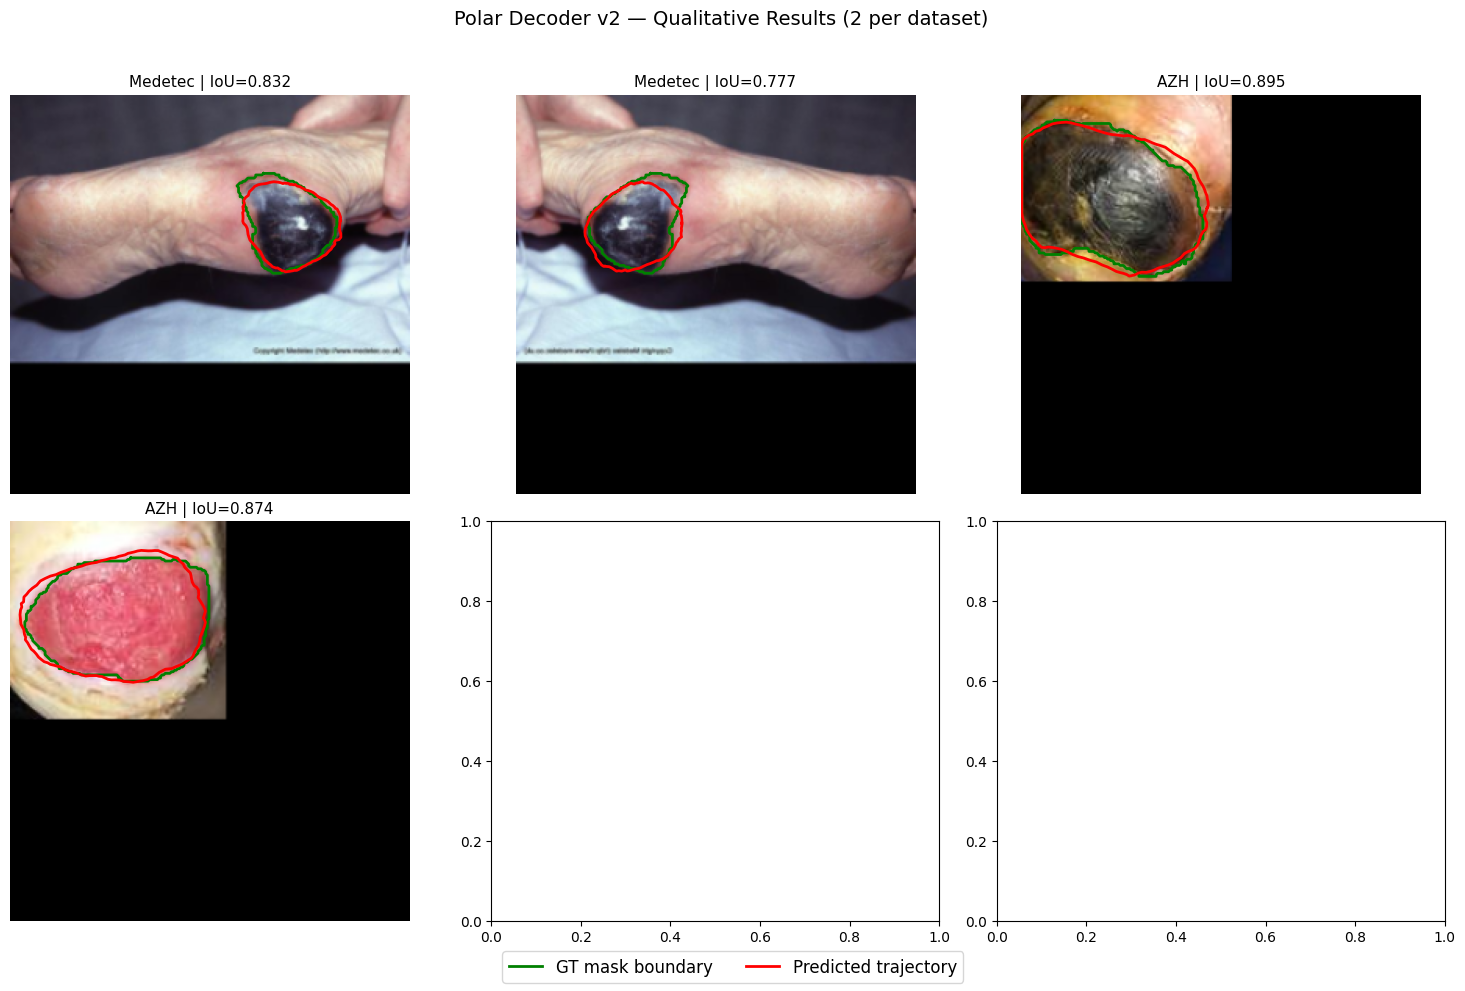

Qualitative figure saved.


In [16]:
# ─── Select 2 images from each real dataset for visualization ──────────────────
MEAN_T = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
STD_T  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denormalize(img_t):
    return (img_t * STD_T + MEAN_T).clamp(0, 1).permute(1,2,0).numpy()

# Group predictions by dataset
preds_by_ds = {}
for p in all_preds:
    ds = p['ds_name']
    if ds == 'synthetic': continue  # skip synthetic
    if ds not in preds_by_ds:
        preds_by_ds[ds] = []
    preds_by_ds[ds].append(p)

print(f'Datasets found: {list(preds_by_ds.keys())}')
for ds, preds in preds_by_ds.items():
    print(f'  {ds}: {len(preds)} test samples')

# Select 2 best IoU samples per dataset (to show the model working well)
# and also select based on diversity
selected = []
for ds_name, preds in preds_by_ds.items():
    # Compute per-sample IoU vs mask for selection
    scored = []
    for p in preds:
        if p['raw_mask'] is not None:
            pp = (p['pred_pts'] * IMAGE_SIZE).astype(np.int32)
            pm = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8)
            cv2.fillPoly(pm, [pp], 1)
            gt = (p['raw_mask'] > 0.5).astype(np.uint8)
            inter = (pm & gt).sum()
            union = (pm | gt).sum()
            iou = inter / union if union > 0 else 0
            scored.append((iou, p))
    scored.sort(key=lambda x: x[0], reverse=True)
    # Take top-2 (best results from this dataset)
    for iou, p in scored[:2]:
        p['iou'] = iou
        p['dataset'] = ds_name
        selected.append(p)

print(f'\nSelected {len(selected)} samples for visualization')

# ─── Plot ──────────────────────────────────────────────────────────────────────
n_show = len(selected)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, sample in enumerate(selected[:6]):
    ax = axes[i]
    img = denormalize(sample['image'])
    ax.imshow(img)

    # Ground truth boundary (from raw mask contour)
    if sample['raw_mask'] is not None:
        mask = (sample['raw_mask'] > 0.5).astype(np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            pts = cnt.squeeze()
            if len(pts.shape) == 2 and len(pts) > 2:
                ax.plot(np.append(pts[:,0], pts[0,0]),
                        np.append(pts[:,1], pts[0,1]),
                        'g-', linewidth=2, label='GT mask' if i==0 else '')

    # Predicted boundary
    pred_px = sample['pred_pts'] * IMAGE_SIZE
    ax.plot(np.append(pred_px[:,0], pred_px[0,0]),
            np.append(pred_px[:,1], pred_px[0,1]),
            'r-', linewidth=2, label='Prediction' if i==0 else '')

    ax.set_title(f"{sample['dataset']} | IoU={sample['iou']:.3f}", fontsize=11)
    ax.axis('off')

fig.legend(['GT mask boundary', 'Predicted trajectory'], loc='lower center',
           ncol=2, fontsize=12, frameon=True)
plt.suptitle('Polar Decoder v2 — Qualitative Results (2 per dataset)', fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('figures/polar_v2/qualitative_per_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('Qualitative figure saved.')

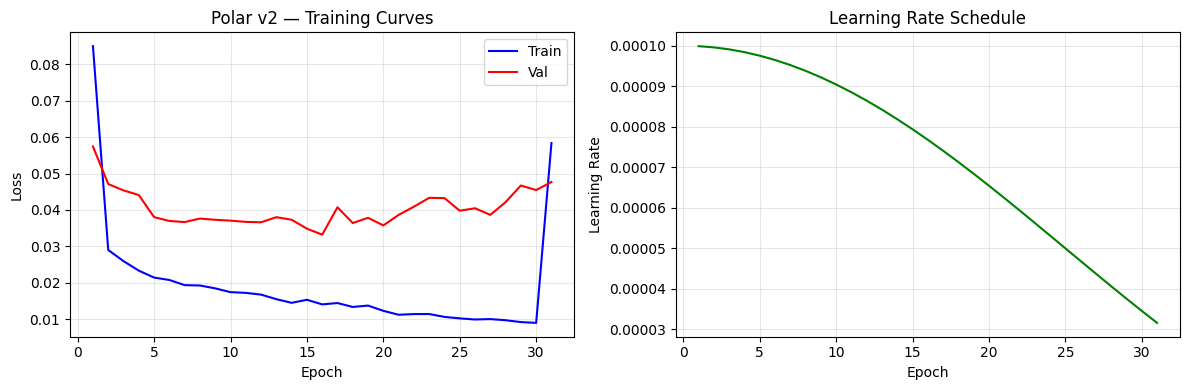

In [17]:
# ─── Training Curves ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(history['train_loss'])+1)
ax1.plot(epochs, history['train_loss'], 'b-', label='Train')
ax1.plot(epochs, history['val_loss'], 'r-', label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Polar v2 — Training Curves'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(epochs, history['lr'], 'g-')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Learning Rate')
ax2.set_title('Learning Rate Schedule'); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/polar_v2/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

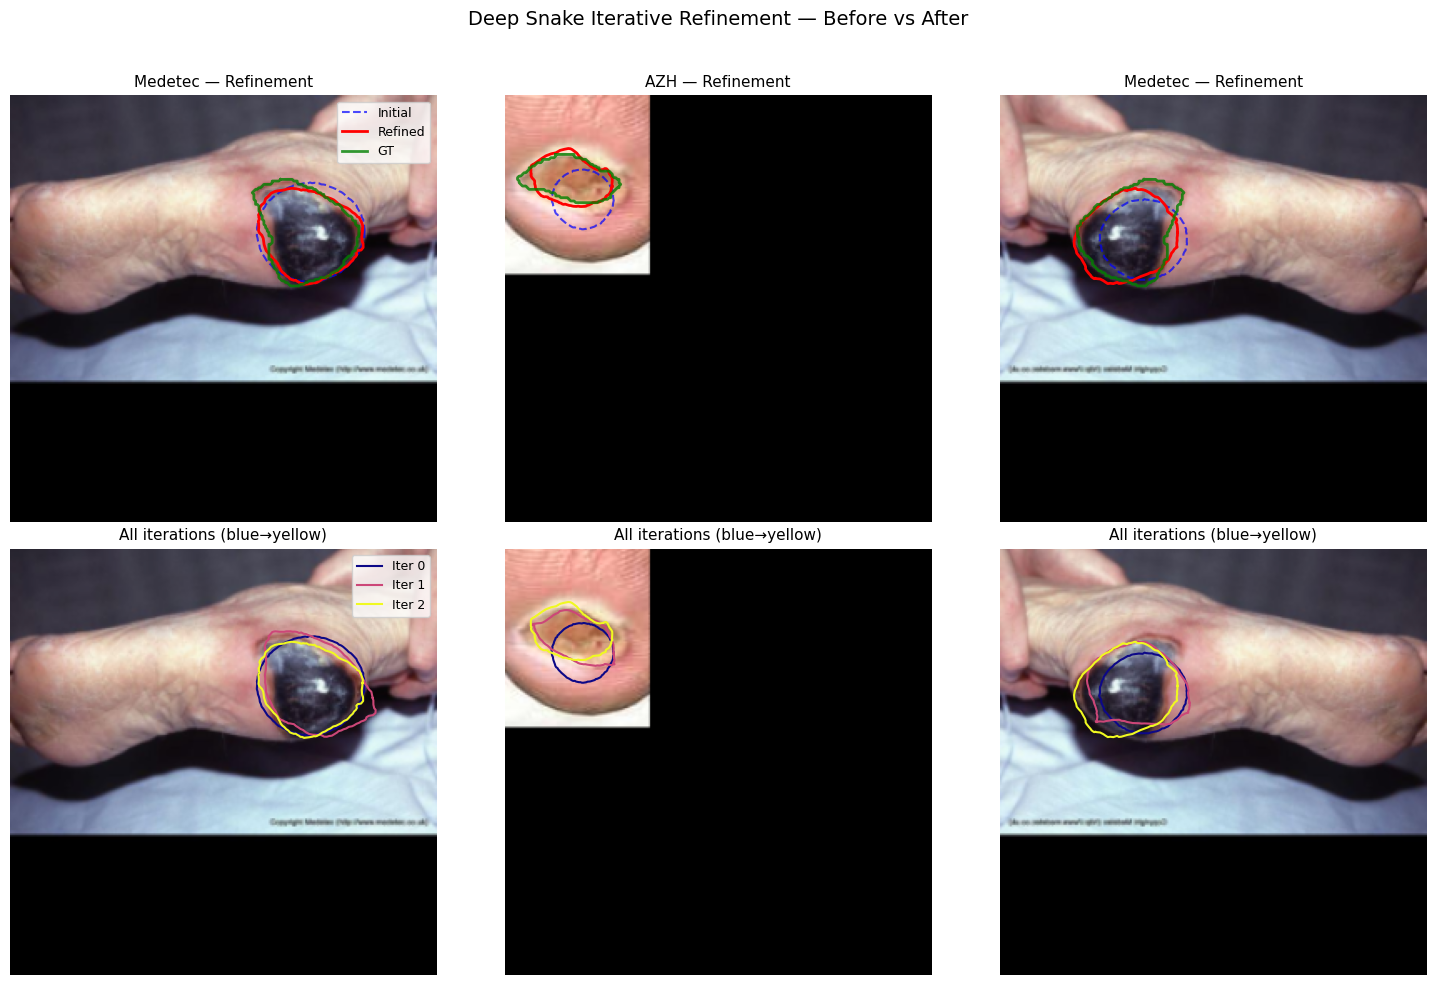

Refinement visualization saved.


In [18]:
# ─── Deep Snake Refinement Visualization ──────────────────────────────────────
# Show how the contour improves across refinement iterations

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# Pick 3 diverse samples (one from each dataset if available)
viz_samples = []
for ds in preds_by_ds.keys():
    if preds_by_ds[ds]:
        viz_samples.append(preds_by_ds[ds][0])
    if len(viz_samples) >= 3:
        break
# Pad with whatever is available
while len(viz_samples) < 3:
    viz_samples.append(all_preds[len(viz_samples)])

# Run model with intermediate outputs
model.eval()
with torch.no_grad():
    for col, sample in enumerate(viz_samples[:3]):
        img = sample['image'].unsqueeze(0).to(device)
        pred = model(img)
        all_pts_list = pred['all_refinement_pts']

        img_np = denormalize(sample['image'])

        # Row 1: Initial (before refinement) vs Final
        ax_top = axes[0, col]
        ax_top.imshow(img_np)
        init_pts = all_pts_list[0][0].cpu().numpy() * IMAGE_SIZE
        final_pts = all_pts_list[-1][0].cpu().numpy() * IMAGE_SIZE
        ax_top.plot(np.append(init_pts[:,0], init_pts[0,0]),
                    np.append(init_pts[:,1], init_pts[0,1]),
                    'b--', linewidth=1.5, alpha=0.7, label='Initial')
        ax_top.plot(np.append(final_pts[:,0], final_pts[0,0]),
                    np.append(final_pts[:,1], final_pts[0,1]),
                    'r-', linewidth=2, label='Refined')
        if sample['raw_mask'] is not None:
            mask = (sample['raw_mask'] > 0.5).astype(np.uint8)
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for cnt in contours:
                pts = cnt.squeeze()
                if len(pts.shape) == 2 and len(pts) > 2:
                    ax_top.plot(np.append(pts[:,0], pts[0,0]),
                                np.append(pts[:,1], pts[0,1]),
                                'g-', linewidth=2, alpha=0.8, label='GT')
        ax_top.set_title(f'{sample["ds_name"]} — Refinement', fontsize=11)
        ax_top.axis('off')
        if col == 0: ax_top.legend(fontsize=9)

        # Row 2: Overlay of all iterations with color gradient
        ax_bot = axes[1, col]
        ax_bot.imshow(img_np)
        colors = plt.cm.plasma(np.linspace(0, 1, len(all_pts_list)))
        for it_idx, pts_iter in enumerate(all_pts_list):
            pts_px = pts_iter[0].cpu().numpy() * IMAGE_SIZE
            ax_bot.plot(np.append(pts_px[:,0], pts_px[0,0]),
                        np.append(pts_px[:,1], pts_px[0,1]),
                        color=colors[it_idx], linewidth=1.5,
                        label=f'Iter {it_idx}' if col == 0 else '')
        ax_bot.set_title(f'All iterations (blue→yellow)', fontsize=11)
        ax_bot.axis('off')
        if col == 0: ax_bot.legend(fontsize=9)

plt.suptitle('Deep Snake Iterative Refinement — Before vs After', fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('figures/polar_v2/deep_snake_refinement.png', dpi=150, bbox_inches='tight')
plt.show()
print('Refinement visualization saved.')

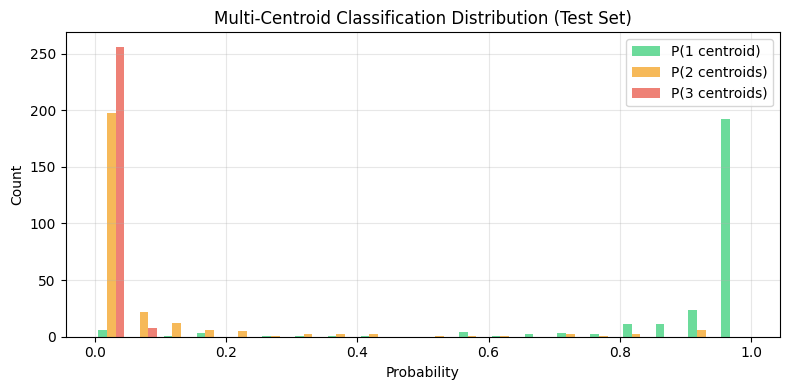

Samples predicted as concave (P(2+3 centroids) > 0.5): 14/264


In [19]:
# ─── Concavity Analysis / Multi-Centroid Demo ─────────────────────────────────
# Show which samples the model detects as concave (would benefit from multi-centroid)

model.eval()
concave_scores = []
with torch.no_grad():
    for batch in test_dl:
        images = batch['image'].to(device)
        with autocast():
            pred = model(images)
        mc = pred['multi_centroid']
        # The classification logits tell us how many centroids the model thinks are needed
        num_probs = F.softmax(mc['num_logits'], dim=-1)  # (B, 3)
        for i in range(len(images)):
            concave_scores.append({
                'p_1': num_probs[i, 0].item(),
                'p_2': num_probs[i, 1].item(),
                'p_3': num_probs[i, 2].item(),
                'ds_name': batch['ds_name'][i] if 'ds_name' in batch else 'unknown',
            })

# Distribution plot
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
p1 = [s['p_1'] for s in concave_scores]
p2 = [s['p_2'] for s in concave_scores]
p3 = [s['p_3'] for s in concave_scores]
ax.hist([p1, p2, p3], bins=20, label=['P(1 centroid)', 'P(2 centroids)', 'P(3 centroids)'],
        alpha=0.7, color=['#2ecc71', '#f39c12', '#e74c3c'])
ax.set_xlabel('Probability')
ax.set_ylabel('Count')
ax.set_title('Multi-Centroid Classification Distribution (Test Set)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/polar_v2/multi_centroid_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

n_concave = sum(1 for s in concave_scores if s['p_2'] + s['p_3'] > 0.5)
print(f'Samples predicted as concave (P(2+3 centroids) > 0.5): {n_concave}/{len(concave_scores)}')

## 7. Summary

In [20]:
print('\n' + '='*60)
print('POLAR DECODER v2 — SUMMARY')
print('='*60)
print(f'Radii resolution:     {NUM_RADII} (doubled from 64)')
print(f'Decoder:              Per-angle cross-attention')
print(f'Refinement:           Deep Snake (2 iterations)')
print(f'Auxiliary:            Fourier descriptor (32 coeffs)')
print(f'Multi-centroid:       Up to 3 (concave detection)')
print(f'Loss:                 MSE + Distance Transform + Fourier consistency')
print(f'Evaluation:           IoU vs RAW MASK (honest metric)')
print('-'*60)
print(f'IoU vs raw mask:      {results["iou_vs_mask"]["mean"]:.4f} +/- {results["iou_vs_mask"]["std"]:.4f}')
print(f'IoU vs polar GT:      {results["iou_vs_polar_gt"]["mean"]:.4f} +/- {results["iou_vs_polar_gt"]["std"]:.4f}')
print(f'Chamfer (px):         {results["chamfer_px"]["mean"]:.2f} +/- {results["chamfer_px"]["std"]:.2f}')
print(f'Test samples:         {results["n_samples"]}')
print('='*60)
print('\nOutput files:')
print('  results/polar_v2/best.pth')
print('  results/polar_v2/metrics.json')
print('  figures/polar_v2/qualitative_per_dataset.png')
print('  figures/polar_v2/training_curves.png')


POLAR DECODER v2 — SUMMARY
Radii resolution:     128 (doubled from 64)
Decoder:              Per-angle cross-attention
Refinement:           Deep Snake (2 iterations)
Auxiliary:            Fourier descriptor (32 coeffs)
Multi-centroid:       Up to 3 (concave detection)
Loss:                 MSE + Distance Transform + Fourier consistency
Evaluation:           IoU vs RAW MASK (honest metric)
------------------------------------------------------------
IoU vs raw mask:      0.5922 +/- 0.1751
IoU vs polar GT:      0.6079 +/- 0.1632
Chamfer (px):         4.56 +/- 2.30
Test samples:         264

Output files:
  results/polar_v2/best.pth
  results/polar_v2/metrics.json
  figures/polar_v2/qualitative_per_dataset.png
  figures/polar_v2/training_curves.png
